In [ ]:
# VAAC-Tiny Algorithm Development

VAAC-Tiny (Vibration-Adaptive Analysis and Classification for TinyML)
is the proposed lightweight vibration analysis and fault classification
algorithm for embedded predictive maintenance.

The algorithm combines:

1. Signal quality assessment
2. Adaptive preprocessing
3. Operating-speed estimation
4. Order-normalized spectral analysis
5. Time-domain vibration features
6. Frequency-domain and bearing-frequency features
7. Lightweight multi-scale 1D-CNN
8. Physics-consistency analysis
9. Confidence-adaptive fusion
10. Temporal consensus
11. Fault severity estimation

The current CWRU benchmark contains four classes:

- Healthy
- Ball
- Inner Race
- Outer Race

Dataset configuration:

Sampling frequency = 12000 Hz
Window length = 12000 samples
Window duration = 1 second
Window overlap = 50%
Window step = 6000 samples
Dataset split = recording-level GroupShuffleSplit
Random state = 42

In [1]:
FS = 12000
WINDOW_SIZE = 12000
OVERLAP = 0.50
STEP_SIZE = 6000
RANDOM_STATE = 42

CLASSES = [
    "Healthy",
    "Ball",
    "Inner Race",
    "Outer Race"
]

NUM_CLASSES = len(CLASSES)

print("Sampling frequency:", FS, "Hz")
print("Window size:", WINDOW_SIZE, "samples")
print("Window duration:", WINDOW_SIZE / FS, "seconds")
print("Overlap:", OVERLAP * 100, "%")
print("Step size:", STEP_SIZE)
print("Classes:", CLASSES)

Sampling frequency: 12000 Hz
Window size: 12000 samples
Window duration: 1.0 seconds
Overlap: 50.0 %
Step size: 6000
Classes: ['Healthy', 'Ball', 'Inner Race', 'Outer Race']


In [2]:
MODEL_INPUT_LENGTH = 12000

OUTPUT_CLASSES = {
    0: "Healthy",
    1: "Ball",
    2: "Inner Race",
    3: "Outer Race"
}

print("Model input:", MODEL_INPUT_LENGTH, "samples")
print("Number of output classes:", len(OUTPUT_CLASSES))

Model input: 12000 samples
Number of output classes: 4


In [3]:
def rpm_to_hz(rpm):
    return rpm / 60.0


example_rpm = 1796

running_frequency = rpm_to_hz(example_rpm)

print("RPM:", example_rpm)
print("Running frequency:", running_frequency, "Hz")

RPM: 1796
Running frequency: 29.933333333333334 Hz


In [5]:
BPFI_MULT = 5.4152
BPFO_MULT = 3.5848
FTF_MULT = 0.39828
RE_MULT = 4.7135

print("BPFI multiplier:", BPFI_MULT)
print("BPFO multiplier:", BPFO_MULT)
print("FTF multiplier:", FTF_MULT)
print("Rolling-element multiplier:", RE_MULT)

BPFI multiplier: 5.4152
BPFO multiplier: 3.5848
FTF multiplier: 0.39828
Rolling-element multiplier: 4.7135


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq

In [7]:
def calculate_bearing_frequencies(running_frequency):
    """
    Calculate expected CWRU bearing characteristic frequencies.
    """

    frequencies = {
        "BPFI": BPFI_MULT * running_frequency,
        "BPFO": BPFO_MULT * running_frequency,
        "FTF": FTF_MULT * running_frequency,
        "RE": RE_MULT * running_frequency
    }

    return frequencies

In [8]:
example_rpm = 1796
running_frequency = example_rpm / 60

bearing_freqs = calculate_bearing_frequencies(running_frequency)

print("Running frequency:", running_frequency, "Hz")

for name, frequency in bearing_freqs.items():
    print(f"{name}: {frequency:.3f} Hz")

Running frequency: 29.933333333333334 Hz
BPFI: 162.095 Hz
BPFO: 107.305 Hz
FTF: 11.922 Hz
RE: 141.091 Hz


In [9]:
from pathlib import Path

WINDOW_ROOT = Path("../data/processed/CWRU/windows")

for path in WINDOW_ROOT.rglob("*.npy"):
    print(path)
    break

..\data\processed\CWRU\windows\test\B007_0_X118_window_0000.npy


In [10]:
WINDOW_ROOT = Path(
    r"C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\windows"
)
window_files = list(WINDOW_ROOT.rglob("*.npy"))

print("Number of windows found:", len(window_files))
print("Example:", window_files[0])

Number of windows found: 583
Example: C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\windows\test\B007_0_X118_window_0000.npy


In [11]:
signal = np.load(window_files[0])

print("Signal shape:", signal.shape)
print("Signal dtype:", signal.dtype)
print("Minimum:", signal.min())
print("Maximum:", signal.max())

Signal shape: (12000,)
Signal dtype: float64
Minimum: -0.5204421556886227
Maximum: 0.5258025149700598


In [12]:
def calculate_fft(signal, fs):
    """
    Calculate one-sided FFT magnitude spectrum.
    """

    n = len(signal)

    signal = signal - np.mean(signal)

    spectrum = np.abs(rfft(signal))

    frequencies = rfftfreq(n, d=1/fs)

    return frequencies, spectrum

In [13]:
frequencies, spectrum = calculate_fft(signal, FS)

print("Frequency bins:", len(frequencies))
print("Frequency resolution:", frequencies[1] - frequencies[0], "Hz")

Frequency bins: 6001
Frequency resolution: 1.0 Hz


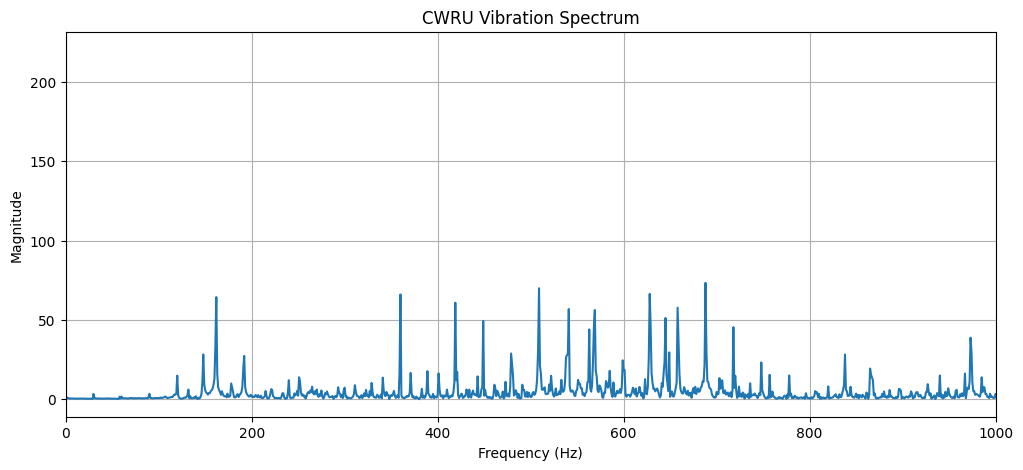

In [14]:

plt.figure(figsize=(12, 5))

plt.plot(frequencies, spectrum)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("CWRU Vibration Spectrum")

plt.xlim(0, 1000)

plt.grid(True)

plt.show()

In [15]:
def spectral_energy_near_frequency(
    frequencies,
    spectrum,
    target_frequency,
    tolerance=5
):
    """
    Calculate spectral energy around a target frequency.
    """

    lower = target_frequency - tolerance
    upper = target_frequency + tolerance

    mask = (
        (frequencies >= lower) &
        (frequencies <= upper)
    )

    if not np.any(mask):
        return 0.0

    energy = np.sum(spectrum[mask] ** 2)

    return energy

In [16]:
def calculate_physics_evidence(signal, fs, running_frequency):
    
    frequencies, spectrum = calculate_fft(signal, fs)

    bearing_freqs = calculate_bearing_frequencies(
        running_frequency
    )

    evidence = {}

    for fault, target_frequency in bearing_freqs.items():

        energy = spectral_energy_near_frequency(
            frequencies,
            spectrum,
            target_frequency
        )

        evidence[fault] = energy

    return evidence

In [17]:
running_frequency = 1796 / 60

evidence = calculate_physics_evidence(
    signal,
    FS,
    running_frequency
)

for fault, value in evidence.items():
    print(f"{fault}: {value:.4e}")

BPFI: 5.9243e+03
BPFO: 1.2314e+01
FTF: 1.6026e+00
RE: 1.9271e+01


In [18]:
def normalize_physics_evidence(evidence):

    total = sum(evidence.values())

    if total == 0:
        return {
            key: 0.0
            for key in evidence
        }

    return {
        key: value / total
        for key, value in evidence.items()
    }

In [19]:
normalized_evidence = normalize_physics_evidence(evidence)

print("Normalized physics evidence:")

for fault, value in normalized_evidence.items():
    print(f"{fault}: {value:.4f}")

Normalized physics evidence:
BPFI: 0.9944
BPFO: 0.0021
FTF: 0.0003
RE: 0.0032


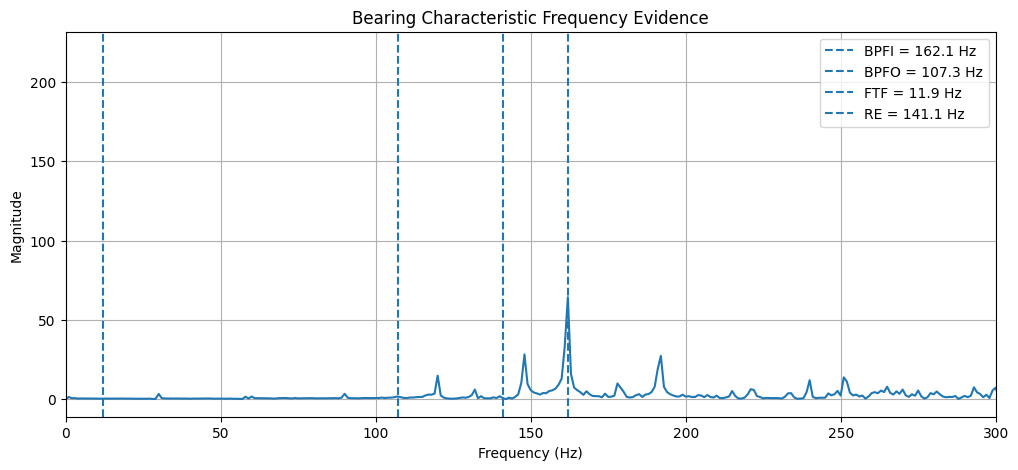

In [20]:
running_frequency = 1796 / 60
bearing_freqs = calculate_bearing_frequencies(running_frequency)

plt.figure(figsize=(12, 5))

plt.plot(frequencies, spectrum)

for name, freq in bearing_freqs.items():
    if freq <= 1000:
        plt.axvline(
            freq,
            linestyle="--",
            label=f"{name} = {freq:.1f} Hz"
        )

plt.xlim(0, 300)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Bearing Characteristic Frequency Evidence")

plt.legend()
plt.grid(True)

plt.show()

In [21]:
test_rpms = [
    1796,
    1772,
    1748,
    1722
]

for rpm in test_rpms:

    running_frequency = rpm / 60

    freqs = calculate_bearing_frequencies(
        running_frequency
    )

    print(f"\nRPM = {rpm}")
    print(f"Running frequency = {running_frequency:.3f} Hz")

    for name, frequency in freqs.items():
        print(f"{name}: {frequency:.3f} Hz")


RPM = 1796
Running frequency = 29.933 Hz
BPFI: 162.095 Hz
BPFO: 107.305 Hz
FTF: 11.922 Hz
RE: 141.091 Hz

RPM = 1772
Running frequency = 29.533 Hz
BPFI: 159.929 Hz
BPFO: 105.871 Hz
FTF: 11.763 Hz
RE: 139.205 Hz

RPM = 1748
Running frequency = 29.133 Hz
BPFI: 157.763 Hz
BPFO: 104.437 Hz
FTF: 11.603 Hz
RE: 137.320 Hz

RPM = 1722
Running frequency = 28.700 Hz
BPFI: 155.416 Hz
BPFO: 102.884 Hz
FTF: 11.431 Hz
RE: 135.277 Hz


In [22]:
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [23]:
def build_vaac_tiny_cnn(
    input_length=12000,
    num_classes=4
):

    inputs = layers.Input(
        shape=(input_length, 1),
        name="vibration_input"
    )

    # Initial feature extraction
    x = layers.Conv1D(
        filters=16,
        kernel_size=7,
        padding="same",
        activation="relu",
        name="initial_conv"
    )(inputs)

    # Multi-scale branch: 3 samples
    branch_3 = layers.SeparableConv1D(
        filters=16,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="scale_3"
    )(x)

    # Multi-scale branch: 7 samples
    branch_7 = layers.SeparableConv1D(
        filters=16,
        kernel_size=7,
        padding="same",
        activation="relu",
        name="scale_7"
    )(x)

    # Multi-scale branch: 15 samples
    branch_15 = layers.SeparableConv1D(
        filters=16,
        kernel_size=15,
        padding="same",
        activation="relu",
        name="scale_15"
    )(x)

    # Combine multi-scale information
    x = layers.Concatenate(
        name="multi_scale_fusion"
    )([
        branch_3,
        branch_7,
        branch_15
    ])

    # Lightweight feature refinement
    x = layers.SeparableConv1D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="feature_refinement"
    )(x)

    # Remove temporal dimension
    x = layers.GlobalAveragePooling1D(
        name="global_average_pooling"
    )(x)

    # Compact dense representation
    x = layers.Dense(
        32,
        activation="relu",
        name="dense_features"
    )(x)

    # Four-class output
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="classification_output"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="VAAC_Tiny_CNN"
    )

    return model

In [24]:
model = build_vaac_tiny_cnn(
    input_length=WINDOW_SIZE,
    num_classes=NUM_CLASSES
)

model.summary()

Model: "VAAC_Tiny_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vibration_input     │ (None, 12000, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_conv        │ (None, 12000, 16) │        128 │ vibration_input[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_3             │ (None, 12000, 16) │        320 │ initial_conv[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_7             │ (None, 12000, 16) │        384 │ initial_conv[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_15            │ (None, 12000, 16) │        512 │ initial_conv[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_scale_fusion  │ (None, 12000, 48) │          0 │ scale_3[0][0],    │
│ (Concatenate)       │                   │            │ scale_7[0][0],    │
│                     │                   │            │ scale_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_refinement  │ (None, 12000, 32) │      1,712 │ multi_scale_fusi… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ feature_refineme… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_features      │ (None, 32)        │      1,056 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 4)         │        132 │ dense_features[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,244 (16.58 KB)

 Trainable params: 4,244 (16.58 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
total_params = model.count_params()

print(
    "Total model parameters:",
    total_params
)

Total model parameters: 4244


In [26]:
dummy_signal = np.zeros(
    (1, WINDOW_SIZE, 1),
    dtype=np.float32
)

print(
    "Dummy input shape:",
    dummy_signal.shape
)

Dummy input shape: (1, 12000, 1)


In [27]:
dummy_output = model.predict(
    dummy_signal,
    verbose=0
)

print(
    "Output shape:",
    dummy_output.shape
)

print(
    "Output probabilities:",
    dummy_output[0]
)

print(
    "Probability sum:",
    np.sum(dummy_output[0])
)

Output shape: (1, 4)
Output probabilities: [0.25 0.25 0.25 0.25]
Probability sum: 1.0


In [28]:
for class_name, probability in zip(
    CLASSES,
    dummy_output[0]
):

    print(
        f"{class_name:12s}: "
        f"{probability:.4f}"
    )

Healthy     : 0.2500
Ball        : 0.2500
Inner Race  : 0.2500
Outer Race  : 0.2500


In [29]:
MODEL_DIR = Path(
    r"C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model.save(
    MODEL_DIR / "vaac_tiny_cnn_prototype.keras"
)

print("Prototype model saved.")

Prototype model saved.
